Correlação entre as variáveis meteorológicas atuais
e a ocorrência de chuva intensa nas próximas horas:



,+1h,+2h,+3h,+4h,+5h,+6h
"PRESSAO ATMOSFERICA AO NIVEL DA ESTACAO, HORARIA (mB)",0.015,0.014,0.012,0.008,0.003,-0.001
PRESSÃO ATMOSFERICA MAX.NA HORA ANT. (AUT) (mB),0.016,0.014,0.012,0.007,0.001,-0.002
PRESSÃO ATMOSFERICA MIN. NA HORA ANT. (AUT) (mB),0.013,0.012,0.008,0.005,0.002,-0.002
"TEMPERATURA DO AR - BULBO SECO, HORARIA (°C)",-0.033,-0.033,-0.036,-0.038,-0.037,-0.034
TEMPERATURA DO PONTO DE ORVALHO (°C),0.048,0.047,0.039,0.037,0.033,0.034
TEMPERATURA MÁXIMA NA HORA ANT. (AUT) (°C),-0.034,-0.036,-0.039,-0.040,-0.039,-0.035
TEMPERATURA MÍNIMA NA HORA ANT. (AUT) (°C),-0.032,-0.035,-0.036,-0.036,-0.033,-0.029
TEMPERATURA ORVALHO MAX. NA HORA ANT. (AUT) (°C),0.042,0.036,0.030,0.025,0.022,0.024
TEMPERATURA ORVALHO MIN. NA HORA ANT. (AUT) (°C),0.055,0.047,0.045,0.043,0.042,0.045
UMIDADE REL. MAX. NA HORA ANT. (AUT) (%),0.061,0.058,0.058,0.057,0.053,0.050


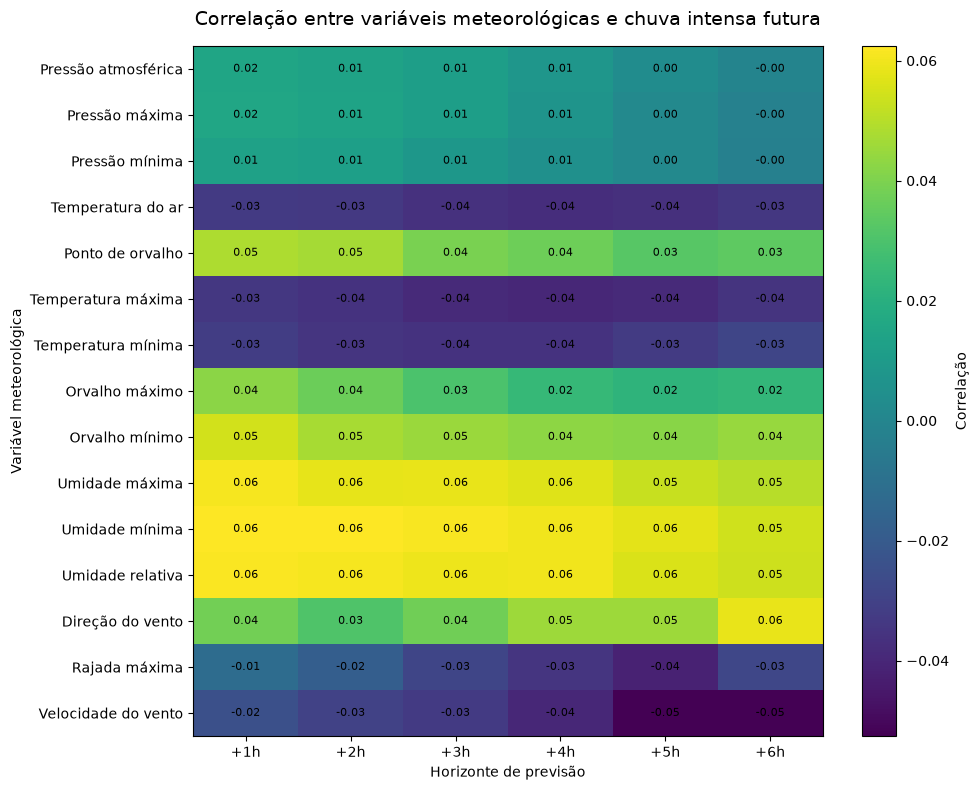

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# 1. CARREGAR OS DADOS
# ============================================================

df = pd.read_csv(
    "../dados/df_recife.csv",
    sep=",",
    encoding="utf-8"
)

# Limpar nomes das colunas
df.columns = df.columns.str.strip()

# Remover coluna de índice
if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])

# ============================================================
# 2. PREPARAR DATA E HORA
# ============================================================

df["Data"] = pd.to_datetime(
    df["Data"],
    errors="coerce"
)

# Criar uma coluna de data/hora completa
df["Hora UTC"] = df["Hora UTC"].astype(str)

df["DataHora"] = pd.to_datetime(
    df["Data"].dt.strftime("%Y-%m-%d") + " " +
    df["Hora UTC"].str.replace(" UTC", "", regex=False).str[:2] + ":00",
    errors="coerce"
)

# Ordenar cronologicamente
df = df.sort_values("DataHora").reset_index(drop=True)

# ============================================================
# 3. PREPARAR A PRECIPITAÇÃO
# ============================================================

col_precipitacao = "PRECIPITAÇÃO TOTAL, HORÁRIO (mm)"

df[col_precipitacao] = (
    df[col_precipitacao]
    .astype(str)
    .str.replace(",", ".", regex=False)
)

df[col_precipitacao] = pd.to_numeric(
    df[col_precipitacao],
    errors="coerce"
)

# ============================================================
# 4. VARIÁVEIS METEOROLÓGICAS
# ============================================================

variaveis = [
    "PRESSAO ATMOSFERICA AO NIVEL DA ESTACAO, HORARIA (mB)",
    "PRESSÃO ATMOSFERICA MAX.NA HORA ANT. (AUT) (mB)",
    "PRESSÃO ATMOSFERICA MIN. NA HORA ANT. (AUT) (mB)",
    "TEMPERATURA DO AR - BULBO SECO, HORARIA (°C)",
    "TEMPERATURA DO PONTO DE ORVALHO (°C)",
    "TEMPERATURA MÁXIMA NA HORA ANT. (AUT) (°C)",
    "TEMPERATURA MÍNIMA NA HORA ANT. (AUT) (°C)",
    "TEMPERATURA ORVALHO MAX. NA HORA ANT. (AUT) (°C)",
    "TEMPERATURA ORVALHO MIN. NA HORA ANT. (AUT) (°C)",
    "UMIDADE REL. MAX. NA HORA ANT. (AUT) (%)",
    "UMIDADE REL. MIN. NA HORA ANT. (AUT) (%)",
    "UMIDADE RELATIVA DO AR, HORARIA (%)",
    "VENTO, DIREÇÃO HORARIA (gr) (° (gr))",
    "VENTO, RAJADA MAXIMA (m/s)",
    "VENTO, VELOCIDADE HORARIA (m/s)"
]

# Converter variáveis para número
for coluna in variaveis:
    df[coluna] = (
        df[coluna]
        .astype(str)
        .str.replace(",", ".", regex=False)
    )

    df[coluna] = pd.to_numeric(
        df[coluna],
        errors="coerce"
    )

# ============================================================
# 5. CRIAR A CHUVA FUTURA DE +1h ATÉ +6h
# ============================================================

for horas in range(1, 7):

    df[f"Chuva_+{horas}h"] = (
        df[col_precipitacao].shift(-horas)
    )

# ============================================================
# 6. DEFINIR CHUVA INTENSA
#    Neste projeto: precipitação > 10 mm/h
# ============================================================

for horas in range(1, 7):

    df[f"Intensa_+{horas}h"] = (
        df[f"Chuva_+{horas}h"] > 10
    ).astype(int)

# ============================================================
# 7. CALCULAR A CORRELAÇÃO
#    Variáveis atuais x chuva intensa futura
# ============================================================

resultados = {}

for horas in range(1, 7):

    coluna_futura = f"Intensa_+{horas}h"

    correlacoes = df[
        variaveis + [coluna_futura]
    ].corr()[coluna_futura]

    correlacoes = correlacoes.drop(coluna_futura)

    resultados[f"+{horas}h"] = correlacoes

correlacoes_futuras = pd.DataFrame(resultados)

# ============================================================
# 8. MOSTRAR A TABELA DE CORRELAÇÕES
# ============================================================

print("Correlação entre as variáveis meteorológicas atuais")
print("e a ocorrência de chuva intensa nas próximas horas:\n")

display(
    correlacoes_futuras.round(3)
)

# ============================================================
# 9. MAPA DE CALOR DAS CORRELAÇÕES
# ============================================================

import numpy as np

# Nomes mais curtos para facilitar a leitura
nomes_curto = {
    "PRESSAO ATMOSFERICA AO NIVEL DA ESTACAO, HORARIA (mB)": "Pressão atmosférica",
    "PRESSÃO ATMOSFERICA MAX.NA HORA ANT. (AUT) (mB)": "Pressão máxima",
    "PRESSÃO ATMOSFERICA MIN. NA HORA ANT. (AUT) (mB)": "Pressão mínima",
    "TEMPERATURA DO AR - BULBO SECO, HORARIA (°C)": "Temperatura do ar",
    "TEMPERATURA DO PONTO DE ORVALHO (°C)": "Ponto de orvalho",
    "TEMPERATURA MÁXIMA NA HORA ANT. (AUT) (°C)": "Temperatura máxima",
    "TEMPERATURA MÍNIMA NA HORA ANT. (AUT) (°C)": "Temperatura mínima",
    "TEMPERATURA ORVALHO MAX. NA HORA ANT. (AUT) (°C)": "Orvalho máximo",
    "TEMPERATURA ORVALHO MIN. NA HORA ANT. (AUT) (°C)": "Orvalho mínimo",
    "UMIDADE REL. MAX. NA HORA ANT. (AUT) (%)": "Umidade máxima",
    "UMIDADE REL. MIN. NA HORA ANT. (AUT) (%)": "Umidade mínima",
    "UMIDADE RELATIVA DO AR, HORARIA (%)": "Umidade relativa",
    "VENTO, DIREÇÃO HORARIA (gr) (° (gr))": "Direção do vento",
    "VENTO, RAJADA MAXIMA (m/s)": "Rajada máxima",
    "VENTO, VELOCIDADE HORARIA (m/s)": "Velocidade do vento"
}

# Copiar tabela
heatmap_data = correlacoes_futuras.copy()

# Trocar nomes
heatmap_data.index = heatmap_data.index.map(nomes_curto)

# ============================================================
# CRIAR O MAPA DE CALOR
# ============================================================

fig, ax = plt.subplots(figsize=(10, 8))

imagem = ax.imshow(
    heatmap_data.values,
    aspect="auto"
)

# Eixo X
ax.set_xticks(range(len(heatmap_data.columns)))
ax.set_xticklabels(heatmap_data.columns)

# Eixo Y
ax.set_yticks(range(len(heatmap_data.index)))
ax.set_yticklabels(heatmap_data.index)

# Valores dentro das células
for i in range(len(heatmap_data.index)):
    for j in range(len(heatmap_data.columns)):
        valor = heatmap_data.iloc[i, j]

        if not np.isnan(valor):
            ax.text(
                j,
                i,
                f"{valor:.2f}",
                ha="center",
                va="center",
                fontsize=8
            )

# Barra lateral indicando a intensidade da correlação
barra = fig.colorbar(imagem, ax=ax)
barra.set_label("Correlação")

ax.set_title(
    "Correlação entre variáveis meteorológicas e chuva intensa futura",
    fontsize=14,
    pad=15
)

ax.set_xlabel("Horizonte de previsão")
ax.set_ylabel("Variável meteorológica")

plt.tight_layout()
plt.show()